# Bosonic SU2 matrix model, Lambda = 2: Final Results 

Notebook created by HLD for the work arXiv: 2503.13368 [quant-ph, hep-th]

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
def get_last_val(df):
    val_list = []
    name_list = []
    for i in range(len(df.columns)):
        lv = df[df.columns[i]].dropna().to_numpy()[-1]
        val_list.append(np.round(lv,5))
        name_list.append(df.columns[i])
    return name_list, val_list

def plot_e(df, ax, Ee):
    ax.axhline(Ee, color = 'red', linestyle='dashed', label = 'Exact energy')
    for i in range(len(df.columns)):
        ax.plot(np.arange(len(df[df.columns[i]])),df[df.columns[i]],
                color = color_list[i], 
                 label=df.columns[i])
    ax.legend()
    ax.set_ylabel('Energy', fontsize = 15)
    ax.set_xlabel('Iterations', fontsize = 13)

def create_df_last_val(df_cs, df_ct, df_ss, df_st, ll, multifold = False, fold = '1f'):
    ns1, vs1 = get_last_val(df_cs)
    nt1, vt1 = get_last_val(df_ct)

    ns2, vs2 = get_last_val(df_ss)
    nt2, vt2 = get_last_val(df_st)
    l_cn = np.concatenate((ns1, nt1), axis = 0)
    l_cv = np.concatenate((vs1, vt1), axis = 0)
    l_sn = np.concatenate((ns2, nt2), axis = 0)
    l_sv = np.concatenate((vs2, vt2), axis = 0)

    df = pd.DataFrame({'name': l_cn, 'cobyla_values': l_cv, 'spsa_values': l_sv})
    df.set_index('name', inplace = True)
    if not multifold:
        df_name =f'results/l{ll}_last_val.csv'
        df.to_csv(df_name)
        print(f'file saved as {df_name}')
    else: 
        df_name =f'results/l{ll}_last_val_{fold}.csv'
        df.to_csv(df_name)
        print(f'file saved as {df_name}')
    return df
            

In [3]:
#Renaming ansatze
su2_ansatz = ['effsu2_Ry_c', 'effsu2_Rz_c', 'effsu2_RyRz_c', 'effsu2_RyY_c',
             'effsu2_Ry_f', 'effsu2_Rz_f', 'effsu2_RyRz_f', 'effsu2_RyY_f']
tl_ansatz = ['tl_Ry_c', 'tl_Rz_c', 'tl_RyRz_c', 'tl_RyY_c',
             'tl_Ry_f', 'tl_Rz_f', 'tl_RyRz_f', 'tl_RyY_f']

# Coupling = 0.2

In [7]:
E_02 = 3.14808
df_02_cs= pd.read_csv('results/qve_l2_l0.2_effsu2_cobyla.csv')
df_02_ct= pd.read_csv('results/qve_l2_l0.2_twolocal_cobyla.csv')
df_02_ss= pd.read_csv('results/qve_l2_l0.2_effsu2_spsa.csv')
df_02_st= pd.read_csv('results/qve_l2_l0.2_twolocal_spsa.csv')

In [9]:
df_02_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_cs.columns = su2_ansatz

df_02_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_ct.columns = tl_ansatz

df_02_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_ss.columns = su2_ansatz

df_02_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_st.columns = tl_ansatz

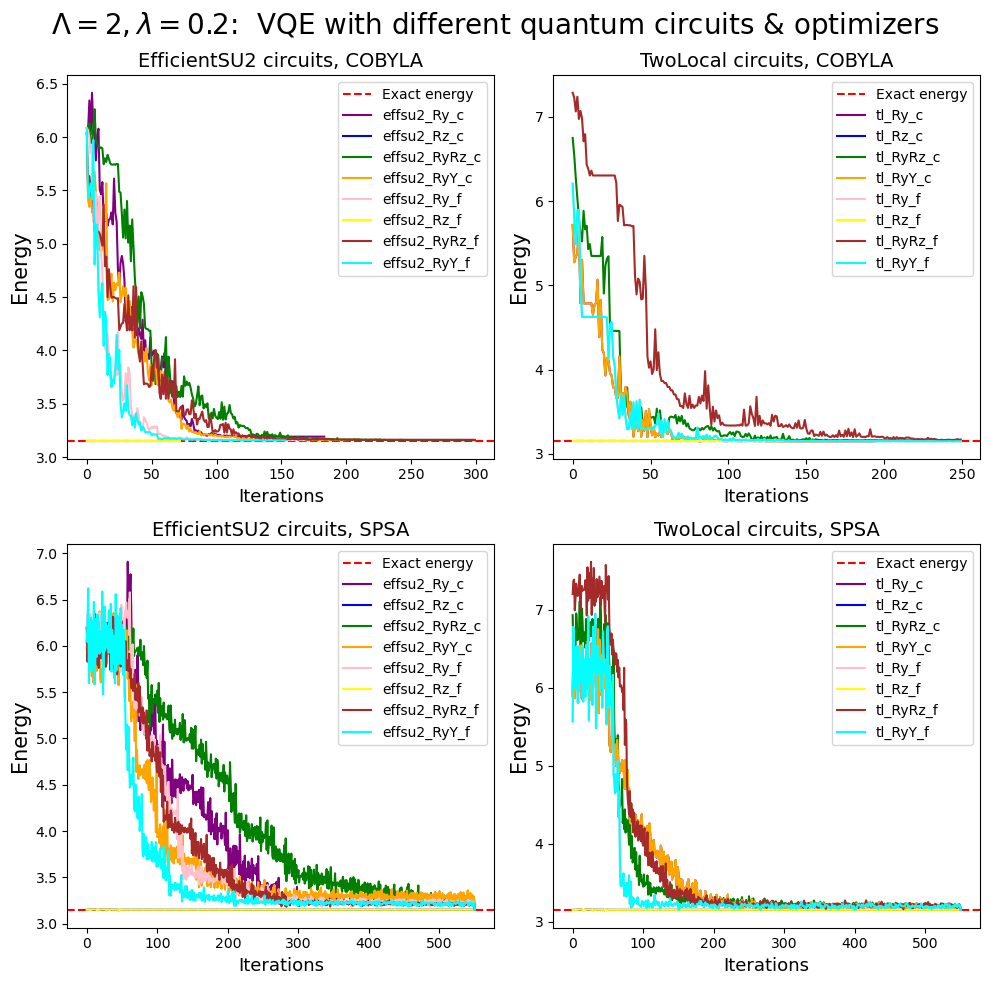

In [11]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_02_cs, ax[0,0], E_02)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 14)

plot_e(df_02_ct, ax[0,1], E_02)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 14)

plot_e(df_02_ss, ax[1,0], E_02)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 14)

plot_e(df_02_st, ax[1,1], E_02)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 14)

plt.suptitle('$\Lambda=2, \lambda=0.2$:  VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('results/L=2_l=02_convergence_curves.png')

In [13]:
df_l02 = create_df_last_val(df_02_cs, df_02_ct, df_02_ss, df_02_st, 0.2)
df_l02

file saved as results/l0.2_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,3.19141,3.15703
effsu2_Rz_c,3.14980,3.14980
effsu2_RyRz_c,3.15801,3.16816
effsu2_RyY_c,3.15977,3.16641
effsu2_Ry_f,3.15918,3.15332
effsu2_Rz_f,3.14980,3.14980
effsu2_RyRz_f,3.16211,3.15137
effsu2_RyY_f,3.15664,3.15137
tl_Ry_c,3.14863,3.14941


In [15]:
df_l02 - E_02

,cobyla_values,spsa_values
name,,
effsu2_Ry_c,0.04333,0.00895
effsu2_Rz_c,0.00172,0.00172
effsu2_RyRz_c,0.00993,0.02008
effsu2_RyY_c,0.01169,0.01833
effsu2_Ry_f,0.01110,0.00524
effsu2_Rz_f,0.00172,0.00172
effsu2_RyRz_f,0.01403,0.00329
effsu2_RyY_f,0.00856,0.00329
tl_Ry_c,0.00055,0.00133


# Coupling = 0.5

In [17]:
E_05 = 3.3625
df_05_cs= pd.read_csv('results/qve_l2_l0.5_effsu2_cobyla.csv')
df_05_ct= pd.read_csv('results/qve_l2_l0.5_twolocal_cobyla.csv')
df_05_ss= pd.read_csv('results/qve_l2_l0.5_effsu2_spsa.csv')
df_05_st= pd.read_csv('results/qve_l2_l0.5_twolocal_spsa.csv')

In [19]:
df_05_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_cs.columns = su2_ansatz

df_05_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_ct.columns = tl_ansatz

df_05_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_ss.columns = su2_ansatz

df_05_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_st.columns = tl_ansatz

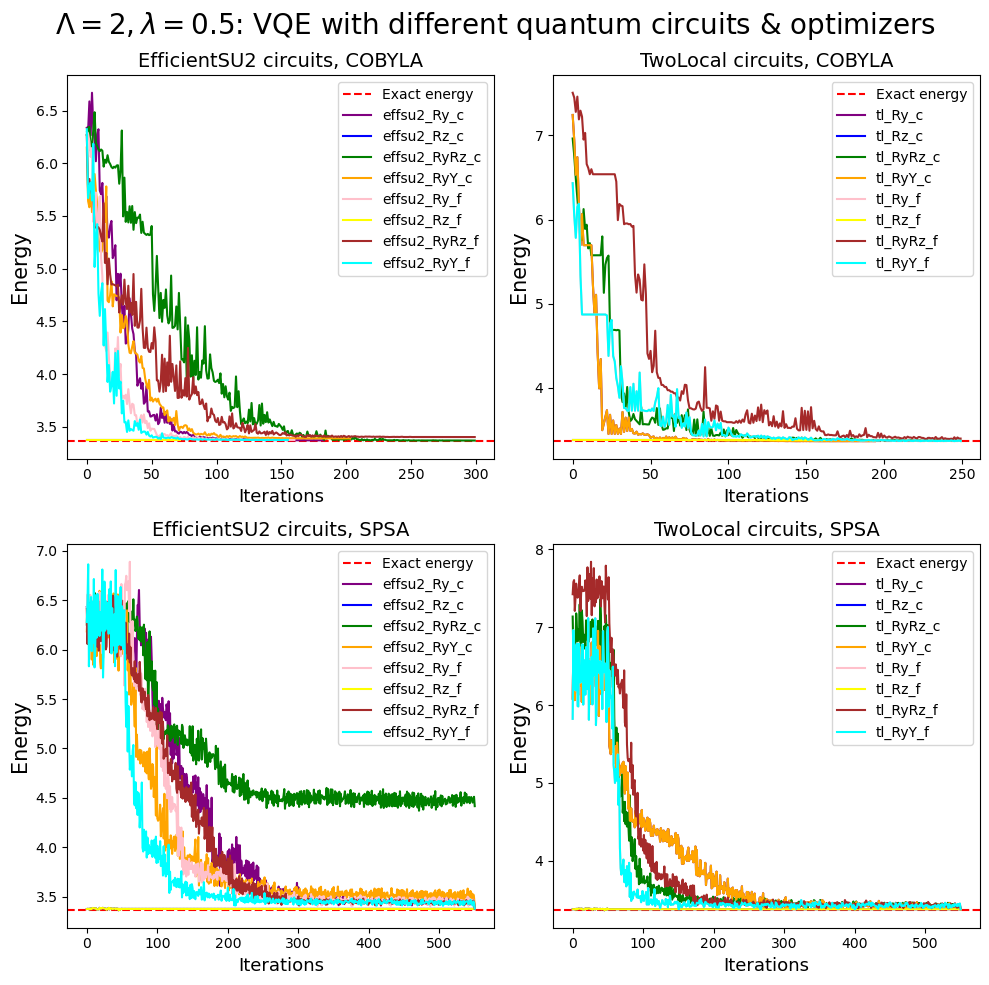

In [21]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_05_cs, ax[0,0], E_05)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 14)

plot_e(df_05_ct, ax[0,1], E_05)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 14)

plot_e(df_05_ss, ax[1,0], E_05)
ax[1,0].set_title('EfficientSU2 circuits, SPSA',fontsize = 14)

plot_e(df_05_st, ax[1,1], E_05)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 14)

plt.suptitle('$\Lambda=2, \lambda=0.5$: VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('results/L=2_l=05_convergence_curves.png')

In [23]:
df_l05 = create_df_last_val(df_05_cs, df_05_ct, df_05_ss, df_05_st, 0.5)
df_l05

file saved as results/l0.5_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,3.37158,3.38623
effsu2_Rz_c,3.37451,3.37451
effsu2_RyRz_c,3.36963,4.41553
effsu2_RyY_c,3.39014,3.40088
effsu2_Ry_f,3.37549,3.37305
effsu2_Rz_f,3.37451,3.37451
effsu2_RyRz_f,3.40283,3.37646
effsu2_RyY_f,3.37549,3.37891
tl_Ry_c,3.36475,3.37207


In [25]:
df_l05 - E_05

,cobyla_values,spsa_values
name,,
effsu2_Ry_c,0.00908,0.02373
effsu2_Rz_c,0.01201,0.01201
effsu2_RyRz_c,0.00713,1.05303
effsu2_RyY_c,0.02764,0.03838
effsu2_Ry_f,0.01299,0.01055
effsu2_Rz_f,0.01201,0.01201
effsu2_RyRz_f,0.04033,0.01396
effsu2_RyY_f,0.01299,0.01641
tl_Ry_c,0.00225,0.00957


# Coupling = 1.0

In [27]:
E_10 = 3.69722
df_10_cs= pd.read_csv('results/qve_l2_l1.0_effsu2_cobyla.csv')
df_10_ct= pd.read_csv('results/qve_l2_l1.0_twolocal_cobyla.csv')
df_10_ss= pd.read_csv('results/qve_l2_l1.0_effsu2_spsa.csv')
df_10_st= pd.read_csv('results/qve_l2_l1.0_twolocal_spsa.csv')

In [29]:
df_10_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_cs.columns = su2_ansatz

df_10_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_ct.columns = tl_ansatz

df_10_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_ss.columns = su2_ansatz

df_10_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_st.columns = tl_ansatz

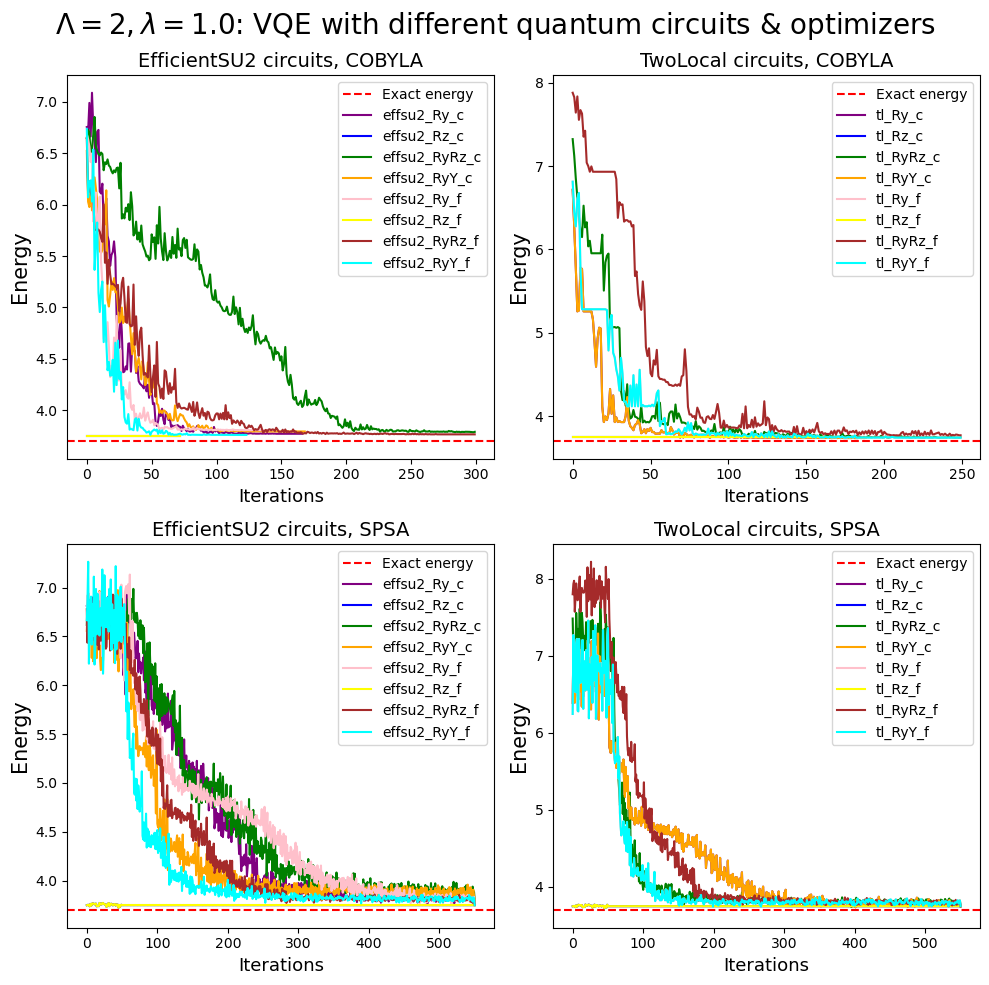

In [31]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_10_cs, ax[0,0], E_10)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 14)


plot_e(df_10_ct, ax[0,1], E_10)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 14)


plot_e(df_10_ss, ax[1,0], E_10)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 14)


plot_e(df_10_st, ax[1,1], E_10)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 14)

plt.suptitle('$\Lambda=2, \lambda=1.0$: VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('results/L=2_l=10_convergence_curves.png')

In [33]:
df_l10 = create_df_last_val(df_10_cs, df_10_ct, df_10_ss, df_10_st, 1.0)
df_l10

file saved as results/l1.0_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,3.77051,3.76953
effsu2_Rz_c,3.74902,3.74902
effsu2_RyRz_c,3.78906,3.79199
effsu2_RyY_c,3.79297,3.77832
effsu2_Ry_f,3.80469,3.74316
effsu2_Rz_f,3.74902,3.74902
effsu2_RyRz_f,3.76465,3.75098
effsu2_RyY_f,3.75879,3.74902
tl_Ry_c,3.73730,3.75098


# Coupling =2.0

In [35]:
E_20 = 4.26795

df_20_cs= pd.read_csv('results/qve_l2_l2.0_effsu2_cobyla.csv')
df_20_ct= pd.read_csv('results/qve_l2_l2.0_twolocal_cobyla.csv')
df_20_ss= pd.read_csv('results/qve_l2_l2.0_effsu2_spsa.csv')
df_20_st= pd.read_csv('results/qve_l2_l2.0_twolocal_spsa.csv')

In [37]:
df_20_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_cs.columns = su2_ansatz

df_20_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ct.columns = tl_ansatz

df_20_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ss.columns = su2_ansatz

df_20_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_st.columns = tl_ansatz

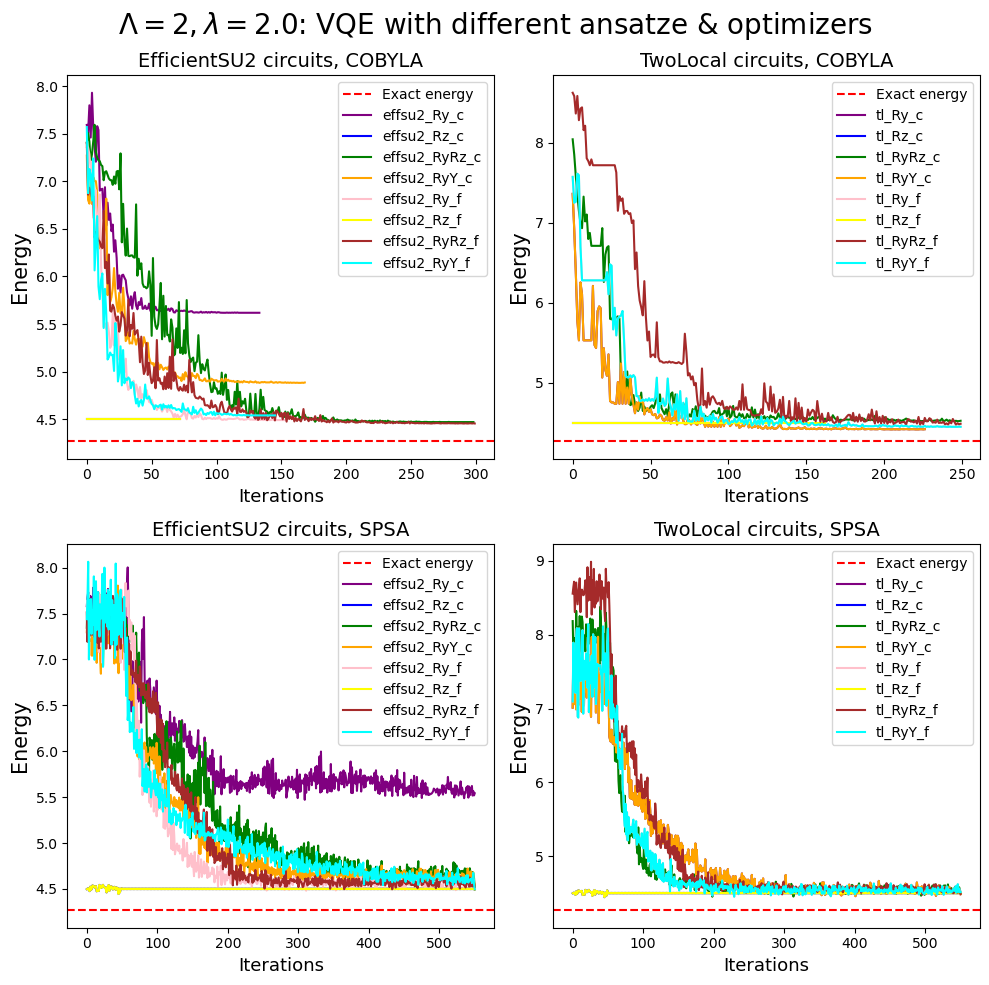

In [39]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_20_cs, ax[0,0], E_20)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 14)

plot_e(df_20_ct, ax[0,1], E_20)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 14)

plot_e(df_20_ss, ax[1,0], E_20)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 14)

plot_e(df_20_st, ax[1,1], E_20)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 14)


plt.suptitle('$\Lambda=2, \lambda=2.0$: VQE with different ansatze & optimizers', fontsize = 20)
plt.savefig('results/L=2_l=20_convergence_curves.png')

In [40]:
df_l20 = create_df_last_val(df_20_cs, df_20_ct, df_20_ss, df_20_st, 2.0)
df_l20

file saved as results/l2.0_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,5.61816,5.54297
effsu2_Rz_c,4.49805,4.49805
effsu2_RyRz_c,4.46973,4.49609
effsu2_RyY_c,4.88574,4.52148
effsu2_Ry_f,4.49121,4.51172
effsu2_Rz_f,4.49805,4.49805
effsu2_RyRz_f,4.45508,4.52051
effsu2_RyY_f,4.54004,4.50098
tl_Ry_c,4.41895,4.48535


# Coupling = 2.0: Multifold circuits

In [20]:
df_20_cs_2f= pd.read_csv('results/qve_l2_l2.0_effsu2_2f_cobyla.csv')
df_20_ct_2f= pd.read_csv('results/qve_l2_l2.0_twolocal_2f_cobyla.csv')
df_20_ss_2f= pd.read_csv('results/qve_l2_l2.0_effsu2_2f_spsa.csv')
df_20_st_2f= pd.read_csv('results/qve_l2_l2.0_twolocal_2f_spsa.csv')

df_20_cs_3f= pd.read_csv('results/qve_l2_l2.0_effsu2_3f_cobyla.csv')
df_20_ct_3f= pd.read_csv('results/qve_l2_l2.0_twolocal_3f_cobyla.csv')
df_20_ss_3f= pd.read_csv('results/qve_l2_l2.0_effsu2_3f_spsa.csv')
df_20_st_3f= pd.read_csv('results/qve_l2_l2.0_twolocal_3f_spsa.csv')

In [21]:
df_20_cs_2f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_cs_2f.columns = su2_ansatz

df_20_ct_2f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ct_2f.columns = tl_ansatz

df_20_ss_2f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ss_2f.columns = su2_ansatz

df_20_st_2f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_st_2f.columns = tl_ansatz

df_20_cs_3f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_cs_3f.columns = su2_ansatz

df_20_ct_3f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ct_3f.columns = tl_ansatz

df_20_ss_3f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ss_3f.columns = su2_ansatz

df_20_st_3f.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_st_3f.columns = tl_ansatz

In [22]:
df_l20_2f = create_df_last_val(df_20_cs_2f, df_20_ct_2f, df_20_ss_2f, df_20_st_2f, 2.0, True, '2f')
df_l20_2f

file saved as results/l2.0_last_val_2f.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,4.46875,4.60547
effsu2_Rz_c,4.49805,4.49805
effsu2_RyRz_c,4.61621,4.53125
effsu2_RyY_c,5.46875,4.53418
effsu2_Ry_f,5.52246,4.52051
effsu2_Rz_f,4.49805,4.49805
effsu2_RyRz_f,4.57715,4.48828
effsu2_RyY_f,5.06152,4.54102
tl_Ry_c,4.46094,4.49219


In [23]:
df_l20_3f = create_df_last_val(df_20_cs_3f, df_20_ct_3f, df_20_ss_3f, df_20_st_3f, 2.0, True, '3f')
df_l20_3f

file saved as results/l2.0_last_val_3f.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,5.45703,5.30566
effsu2_Rz_c,4.49805,4.49805
effsu2_RyRz_c,5.93848,5.97559
effsu2_RyY_c,5.01367,5.40137
effsu2_Ry_f,4.67676,4.51562
effsu2_Rz_f,4.49805,4.49805
effsu2_RyRz_f,4.88281,4.59570
effsu2_RyY_f,4.64258,4.50293
tl_Ry_c,4.44531,4.51562


# Find best ansatz

In [43]:
def find_best_ansatz(df, Ee):
    c_i = np.argmin(np.abs(df['cobyla_values']- Ee))
    print(f'Exact energy is {Ee}')
    print(f'Best ansatz for COBYLA is {df.index[c_i]} with value: {df.cobyla_values[c_i]}')
    s_i = np.argmin(np.abs(df['spsa_values']- Ee))
    print(f'Best ansatz for SPSA is {df.index[s_i]} with value: {df.spsa_values[s_i]}')
    diff_c = np.abs(df.cobyla_values[c_i]-Ee)
    diff_s = np.abs(df.spsa_values[s_i]-Ee)
    if diff_c < diff_s:
        print(f'Best ansatz overall is {df.index[c_i]}')
    if diff_c > diff_s:
         print(f'Best ansatz overall is {df.index[s_i]}')

In [45]:
find_best_ansatz(df_l02, E_02)

Exact energy is 3.14808
Best ansatz for COBYLA is tl_Ry_f with value: 3.14844
Best ansatz for SPSA is tl_Ry_c with value: 3.14941
Best ansatz overall is tl_Ry_f


In [47]:
find_best_ansatz(df_l05, E_05)

Exact energy is 3.3625
Best ansatz for COBYLA is tl_Ry_c with value: 3.36475
Best ansatz for SPSA is tl_Ry_c with value: 3.37207
Best ansatz overall is tl_Ry_c


In [49]:
find_best_ansatz(df_l10, E_10)

Exact energy is 3.69722
Best ansatz for COBYLA is tl_Ry_c with value: 3.7373
Best ansatz for SPSA is effsu2_Ry_f with value: 3.74316
Best ansatz overall is tl_Ry_c


In [51]:
find_best_ansatz(df_l20, E_20)

Exact energy is 4.26795
Best ansatz for COBYLA is tl_Ry_c with value: 4.41895
Best ansatz for SPSA is tl_Ry_c with value: 4.48535
Best ansatz overall is tl_Ry_c


In [29]:
find_best_ansatz(df_l20_2f, E_20)

Exact energy is 4.26795
Best ansatz for COBYLA is tl_RyY_c with value: 4.4082
Best ansatz for SPSA is tl_Ry_f with value: 4.47656
Best ansatz overall is tl_RyY_c


In [30]:
find_best_ansatz(df_l20_3f, E_20)

Exact energy is 4.26795
Best ansatz for COBYLA is tl_Ry_c with value: 4.44531
Best ansatz for SPSA is tl_RyRz_f with value: 4.49609
Best ansatz overall is tl_Ry_c


# Plot all results

In [53]:
E_02 = 3.14808
E_05 = 3.3625
E_10 = 3.69722
E_20 = 4.26795

In [55]:
df_l02 = pd.read_csv('results/l0.2_last_val.csv')
df_l05 = pd.read_csv('results/l0.5_last_val.csv')
df_l10 = pd.read_csv('results/l1.0_last_val.csv')
df_l20 = pd.read_csv('results/l2.0_last_val.csv')
#df_l20_2f = pd.read_csv('results/l2.0_2f_last_val.csv')
df_l02.set_index('name', inplace = True)
df_l05.set_index('name', inplace = True)
df_l10.set_index('name', inplace = True)
df_l20.set_index('name', inplace = True)
#df_l20_2f.set_index('name', inplace = True)

In [57]:
def plot_ax(ax, df, E_e, ll, ylimit = False, yrange = [0.05, 0.5]):
    ax.plot(df['cobyla_values'], color='green', marker='o', linestyle='dashed', label='cobyla')
    ax.plot(df['spsa_values'], color='purple', marker='o', linestyle='dashed', label = 'spsa')
    ax.axhline(E_e, color = 'red', label='Exact energy')
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    ax.set_title(f'$\lambda$ = {ll}', fontsize = 18)
    if ylimit:
        ax.set_ylim(E_e -yrange[0], E_e+ yrange[1])
    ax.set_ylabel('Energy', fontsize = 15)
    ax.legend()
    ax.xaxis.grid(True)   

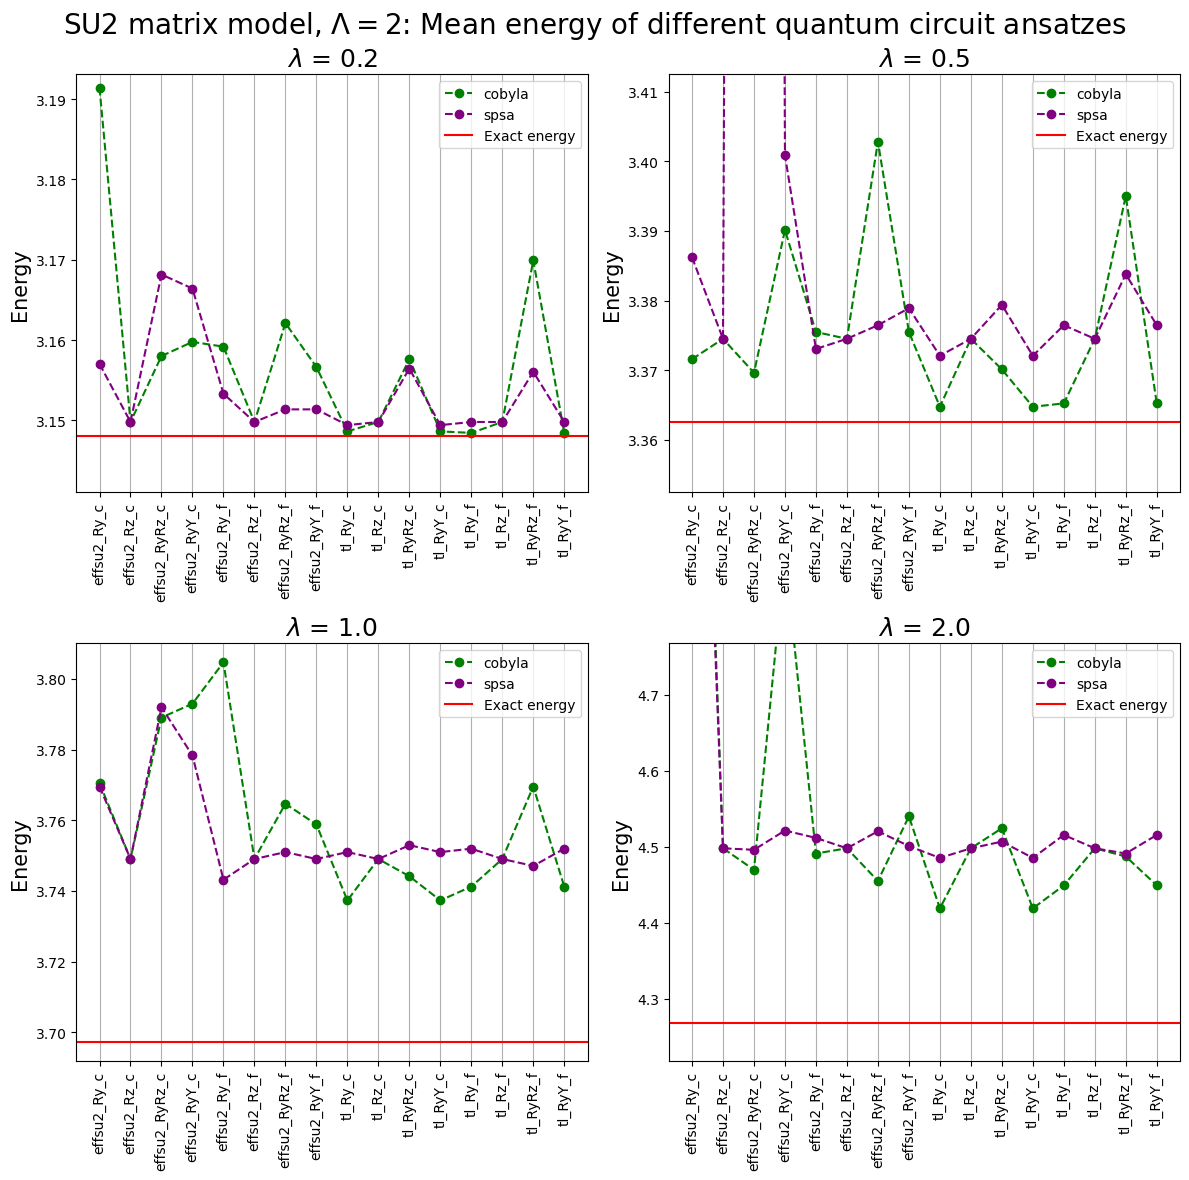

In [77]:
fig, ax = plt.subplots(2,2, figsize = (12,12), tight_layout= True)
plot_ax(ax[0,0], df_l02, E_02, 0.2)
ax[0,0].set_ylim([E_02 - 0.007, E_02 + 0.045])
plot_ax(ax[0,1], df_l05, E_05, 0.5, True, [0.01, 0.05])
plot_ax(ax[1,0], df_l10, E_10, 1.0)
plot_ax(ax[1,1], df_l20, E_20, 2.0, True, [0.05, 0.5])

plt.suptitle('SU2 matrix model, $\Lambda=2$: Mean energy of different quantum circuit ansatzes', fontsize = 20)
plt.savefig('results/L=2_all_ansatze_1f.png')

In [36]:
def plot_ax_mf(ax, df1, df2, df3):
    ax.plot(df1['cobyla_values'],  color='green', marker='o', linestyle='dashed',label='depth-1_cobyla')
    ax.plot(df1['spsa_values'],  color='purple', marker='o', linestyle='dashed',label = 'depth-1_spsa')
    ax.plot(df2['cobyla_values'],  color='orange', marker='o', linestyle='dashed',label='depth-2_cobyla')
    ax.plot(df2['spsa_values'],  color='blue', marker='o', linestyle='dashed',label = 'depth-2_spsa')
    ax.plot(df3['cobyla_values'],  color='cyan', marker='o', linestyle='dashed',label='depth-3_cobyla')
    ax.plot(df3['spsa_values'],  color='pink', marker='o', linestyle='dashed',label = 'depth-3_spsa')
    ax.axhline(E_20, color = 'red', label='Exact energy')
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    #ax.set_title('$\lambda$ = 2.0', fontsize = 18)
    #ax.set_ylim([4.2, 4.8])
    ax.xaxis.grid(True)
    ax.legend(loc = 'upper right')
    

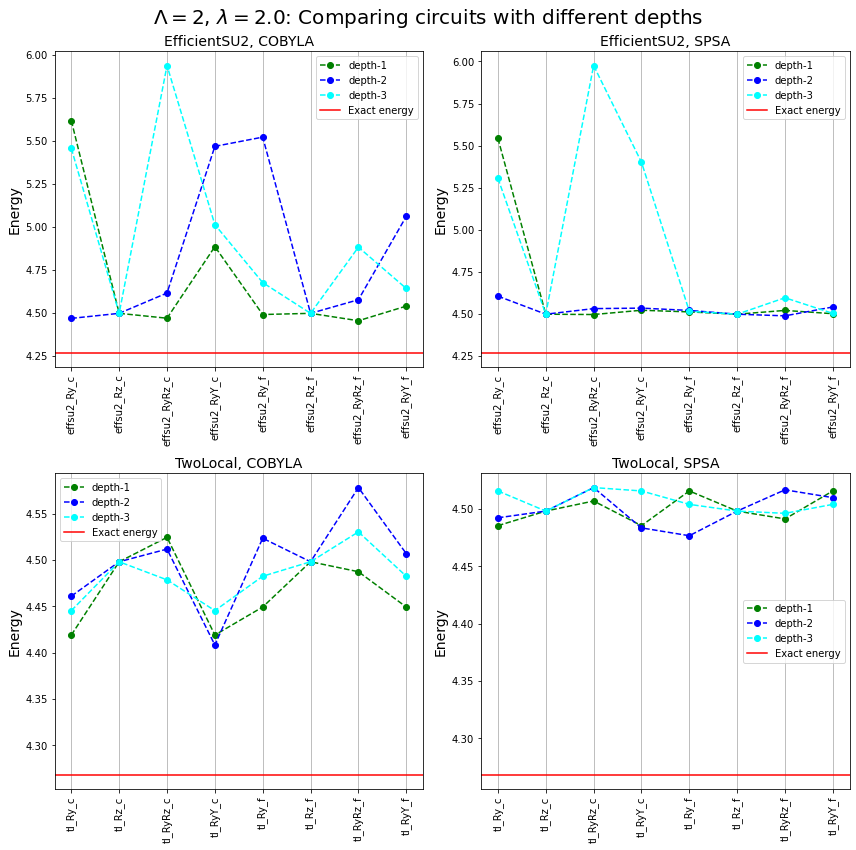

In [38]:
fig, ax = plt.subplots(2,2, figsize = (12,12), tight_layout= True)

ax[0,0].plot(df_l20['cobyla_values'][:8], color='green', marker='o', linestyle='dashed',label='depth-1')
ax[0,0].plot(df_l20_2f['cobyla_values'][:8], color='blue', marker='o', linestyle='dashed',label='depth-2')
ax[0,0].plot(df_l20_3f['cobyla_values'][:8], color='cyan', marker='o', linestyle='dashed',label='depth-3')
ax[0,0].axhline(E_20, color = 'red', label='Exact energy')
for tick in ax[0,0].get_xticklabels():
    tick.set_rotation(90)
ax[0,0].set_title('EfficientSU2, COBYLA', fontsize = 14)
#ax.set_ylim([4.2, 4.8])
ax[0,0].xaxis.grid(True)
ax[0,0].set_ylabel('Energy', fontsize = 14)
ax[0,0].legend(loc = 'upper right')

ax[0,1].plot(df_l20['spsa_values'][:8], color='green', marker='o', linestyle='dashed',label = 'depth-1')
ax[0,1].plot(df_l20_2f['spsa_values'][:8], color='blue', marker='o', linestyle='dashed',label = 'depth-2')
ax[0,1].plot(df_l20_3f['spsa_values'][:8], color='cyan', marker='o', linestyle='dashed',label = 'depth-3')
ax[0,1].axhline(E_20, color = 'red', label='Exact energy')
for tick in ax[0,1].get_xticklabels():
    tick.set_rotation(90)
ax[0,1].set_title('EfficientSU2, SPSA', fontsize = 14)
#ax.set_ylim([4.2, 4.8])
ax[0,1].xaxis.grid(True)
ax[0,1].set_ylabel('Energy', fontsize = 14)
ax[0,1].legend(loc = 'best')

ax[1,0].plot(df_l20['cobyla_values'][8:], color='green', marker='o', linestyle='dashed',label='depth-1')
ax[1,0].plot(df_l20_2f['cobyla_values'][8:], color='blue', marker='o', linestyle='dashed',label='depth-2')
ax[1,0].plot(df_l20_3f['cobyla_values'][8:], color='cyan', marker='o', linestyle='dashed',label='depth-3')
ax[1,0].axhline(E_20, color = 'red', label='Exact energy')
for tick in ax[1,0].get_xticklabels():
    tick.set_rotation(90)
ax[1,0].set_title('TwoLocal, COBYLA', fontsize = 14)
#ax.set_ylim([4.2, 4.8])
ax[1,0].xaxis.grid(True)
ax[1,0].set_ylabel('Energy', fontsize = 14)
ax[1,0].legend(loc = 'best')


ax[1,1].plot(df_l20['spsa_values'][8:], color='green', marker='o', linestyle='dashed',label = 'depth-1')
ax[1,1].plot(df_l20_2f['spsa_values'][8:], color='blue', marker='o', linestyle='dashed',label = 'depth-2')
ax[1,1].plot(df_l20_3f['spsa_values'][8:], color='cyan', marker='o', linestyle='dashed',label = 'depth-3')
ax[1,1].axhline(E_20, color = 'red', label='Exact energy')
for tick in ax[1,1].get_xticklabels():
    tick.set_rotation(90)
ax[1,1].set_title('TwoLocal, SPSA', fontsize = 14)
#ax.set_ylim([4.2, 4.8])
ax[1,1].xaxis.grid(True)
ax[1,1].set_ylabel('Energy', fontsize = 14)
ax[1,1].legend(loc = 'best')

plt.suptitle('$\Lambda=2$, $\lambda=2.0$: Comparing circuits with different depths', fontsize = 20)
plt.savefig('results/L=2_l=20_all_ansatze_mf.png')